# 2. Clustering (K-Means)

Mengelompokkan tweet tanpa label berdasarkan kemiripan kata.

Alur: teks → **TF-IDF** (teks jadi angka, stopwords dibuang) → **K-Means** → lihat kata dominan tiap cluster → **silhouette score** → visualisasi **PCA** 2D.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

nltk.download('stopwords')
from nltk.corpus import stopwords as stopwords_scratch

KEYWORD = "karhutla"   
data = pd.read_csv(f"data/{KEYWORD}_clean.csv").dropna()
data

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,full_text
0,penegakan hukum karhutla memang bergerak tetap...
1,kejagung menerima spdp perkara pidana karhutla...
2,polsek menjalin edukasi warga cegah karhutla s...
3,karhutla di amburawang laut meluas tim gabunga...
4,di tengah kepungan api dan asap orangutan beru...
...,...
256,perkara apa mereka kesel sama kita gara asep k...
257,jends menurut kalian kl cowo pacarmu gamau dia...
258,bnpb jumlah titik karhutla makin meningkat di ...
259,karhutla di pulau karakelang talaud sulawesi u...


## Stopwords
Stopwords = kata umum yang tidak bermakna untuk analisis (yang, di, dan, the, ...). Ditambah kata gaul dan **keyword itu sendiri**, karena keyword muncul di hampir semua tweet sehingga tidak membedakan cluster.

In [3]:
list_stopwords = stopwords_scratch.words('indonesian')
list_stopwords.extend(stopwords_scratch.words('english'))
list_stopwords.extend([
    'ya', 'yg', 'ga', 'gak', 'ngga', 'nggak', 'engga', 'enggak', 'yuk', 'dah',
    'aja', 'sih', 'nih', 'tuh', 'dong', 'deh', 'kok', 'lah', 'nya', 'kalo',
    'gue', 'gw', 'lu', 'lo', 'udah', 'jd', 'dgn', 'utk', 'tdk', 'sm', 'sj',
    'bang', 'pak', 'amp',
    KEYWORD,
])
stopwords = sorted(set(list_stopwords))
print("Jumlah stopwords:", len(stopwords))

Jumlah stopwords: 985


## Ubah data menjadi list

In [4]:
texts = data['full_text'].astype(str).to_list()
texts[:10]

['penegakan hukum karhutla memang bergerak tetapi pergerakannya belum sama antara pelaku perorangan dan korporasi yang perlu dilihat berikutnya adalah apa yang membuat perkara korporasi belum sampai pada penetapan tersangka',
 'kejagung menerima spdp perkara pidana karhutla sepanjang januari september perkara perorangan dan perkara korporasi sebanyak perkara sudah p dan dilimpahkan ke pengadilan namun seluruh perkara korporasi masih berada dalam tahap penyidikan',
 'polsek menjalin edukasi warga cegah karhutla sejak dini',
 'karhutla di amburawang laut meluas tim gabungan berjibaku padamkan api jam',
 'di tengah kepungan api dan asap orangutan berusia sekitar tahun ditemukan bertahan di atas pohon di kawasan katune palangka raya simak video selengkapnya di',
 'cegah api sebelum berkobar polsek muara kaman sisir kawasan rawan karhutla',
 'karhutla di samboja bakar hektare lahan gambut tim gabungan bergerak cepat kukar kebakaran lahan gambut dan semak belukar terjadi di rt kelurahan wono

## TF-IDF Vectorizer
`min_df=2` artinya kata yang cuma muncul di 1 tweet diabaikan (biasanya typo/nama acak), sehingga cluster lebih bermakna. Di laprak contoh hanya dipakai 100 data (`data[:100]`); di sini dipakai **semua** data.

In [5]:
vectorizer = TfidfVectorizer(stop_words=stopwords, min_df=2)
X = vectorizer.fit_transform(texts)
print("Bentuk matriks (jumlah tweet, jumlah kata):", X.shape)

Bentuk matriks (jumlah tweet, jumlah kata): (261, 502)


D:\SEMESTER 5\Aplikasi Web\streamlit\week5\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


## Menentukan jumlah cluster (k)
Dicoba beberapa nilai k, lalu dibandingkan silhouette score-nya (makin tinggi makin baik). Ini opsional, tapi bagus untuk menjelaskan di laporan **kenapa** memilih k tertentu.

k=2: silhouette=0.0177
k=3: silhouette=0.0216
k=4: silhouette=0.0231
k=5: silhouette=0.0260
k=6: silhouette=0.0268
k=7: silhouette=0.0272
k=8: silhouette=0.0306
k=9: silhouette=0.0319
k=10: silhouette=0.0295


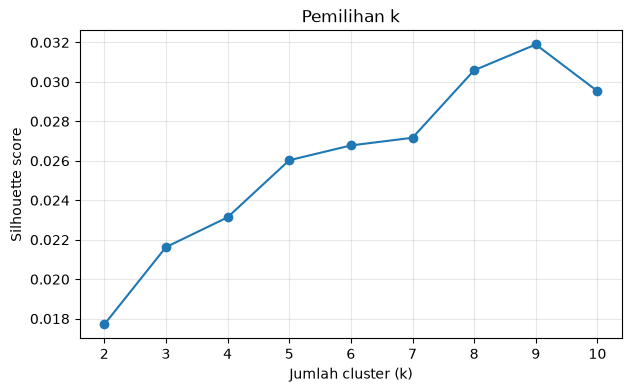

In [6]:
k_range = range(2, 11)
scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))
    print(f"k={k}: silhouette={scores[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), scores, marker='o')
plt.xlabel('Jumlah cluster (k)')
plt.ylabel('Silhouette score')
plt.title('Pemilihan k')
plt.grid(alpha=.3)
plt.show()

## K-Means
Ubah `true_k` sesuai hasil di atas (atau tetap 8 seperti contoh laprak).

In [7]:
true_k = 8
model = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=10, random_state=42)
model.fit(X)

,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",100
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 502)","[[0

## Menampilkan cluster
Kata dengan bobot tertinggi di pusat (centroid) tiap cluster = ciri khas cluster tersebut.

In [8]:
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(true_k):
    jumlah = (model.labels_ == i).sum()
    print(f"Cluster {i} ({jumlah} tweet):")
    print("  " + ", ".join(terms[ind] for ind in order_centroids[i, :10]))
    print()

Cluster 0 (47 tweet):
  lahan, api, hutan, kebakaran, tim, gabungan, cegah, padamkan, wilayah, gambut

Cluster 1 (23 tweet):
  jepang, misi, kalimantan, menhan, kasih, pemadaman, bantu, sjafrie, terima, bantuan

Cluster 2 (20 tweet):
  asap, bangun, kota, cik, kabut, pagi, palembang, malaysia, polusi, kebakaran

Cluster 3 (25 tweet):
  semoga, aman, palangka, raya, asap, rumah, warga, honor, kondisi, bertahan

Cluster 4 (20 tweet):
  masyarakat, bantuan, terdampak, kebutuhan, kondisi, kalteng, khbs, program, penanganan, betang

Cluster 5 (84 tweet):
  kena, asep, perkara, titik, gimana, panas, penanganan, hujan, pemadaman, kelar

Cluster 6 (21 tweet):
  negara, indonesia, indo, maki, terdampak, gimana, pemerintah, jir, korupsi, jg

Cluster 7 (21 tweet):
  patroli, polsek, cegah, rawan, kegiatan, sosialisasi, melaksanakan, desa, blangpidie, pencegahan



## Silhouette score
Rentang -1 s/d 1. Mendekati 1 = cluster terpisah jelas; mendekati 0 = cluster saling tumpang tindih; negatif = banyak data salah cluster.

Untuk teks pendek seperti tweet, nilai kecil (±0.01–0.05) itu wajar.

In [9]:
score = silhouette_score(X, labels=model.labels_)
print(f"Silhouette score: {score:.4f}")

Silhouette score: 0.0306


## Visualisasi PCA
TF-IDF punya ribuan dimensi, jadi diringkas ke 2 dimensi dengan PCA supaya bisa digambar. Tanda **X** merah = pusat cluster.

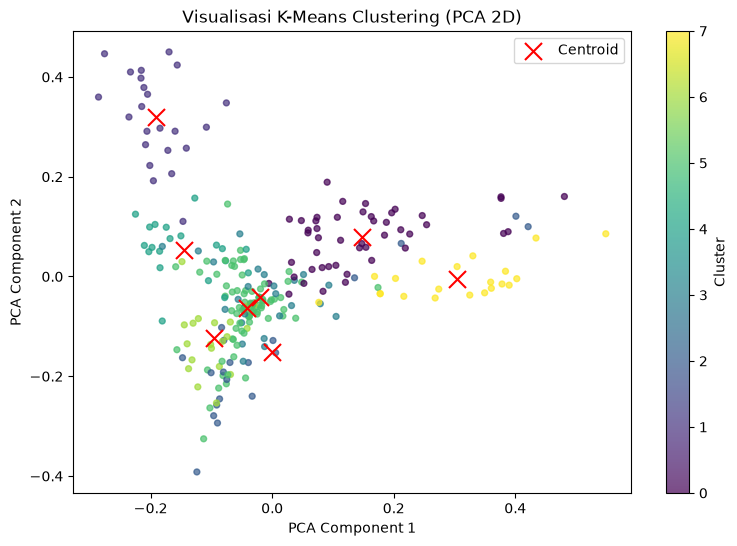

In [10]:
pca = PCA(n_components=2, random_state=0)
reduced_features = pca.fit_transform(X.toarray())
reduced_cluster_centers = pca.transform(model.cluster_centers_)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1],
                      c=model.labels_, cmap='viridis', s=18, alpha=.7)
plt.scatter(reduced_cluster_centers[:, 0], reduced_cluster_centers[:, 1],
            marker='x', s=150, c='red', label='Centroid')
plt.colorbar(scatter, label='Cluster')
plt.title('Visualisasi K-Means Clustering (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

## Lihat contoh tweet per cluster + simpan
Berguna untuk menulis analisis di laporan (cluster X membahas apa).

In [11]:
data['cluster'] = model.labels_
for i in range(true_k):
    print(f"--- Cluster {i} ---")
    for t in data[data['cluster'] == i]['full_text'].head(3):
        print("•", t[:120])
    print()

data.to_csv(f"data/{KEYWORD}_clustered.csv", index=False)

--- Cluster 0 ---
• karhutla di amburawang laut meluas tim gabungan berjibaku padamkan api jam
• karhutla di samboja bakar hektare lahan gambut tim gabungan bergerak cepat kukar kebakaran lahan gambut dan semak beluka
• cegah karhutla sejak dini polsek sangasanga rutin pantau wilayah rawan kukar upaya mencegah kebakaran hutan dan lahan ka

--- Cluster 1 ---
• terharu kementerian pertahanan jepang resmi mengakhiri operasi bantuan penanggulangan karhutla di k
• beredar narasi bahwa jepang gagal memadamkan kebakaran hutan dan lahan di kalimantan lalu pulang karena tidak sanggup ca
• misi bantuan jepang buat karhutla di kalimantan resmi berakhir terima kasih sdf sorti ton air

--- Cluster 2 ---
• cegah karhutla makin meluas polsek kota bangun ingatkan warga soal bahaya membakar lahan kukar upaya mencegah kebakaran 
• cegah karhutla makin meluas polsek kota bangun ingatkan warga soal bahaya membakar lahan kukar upaya mencegah kebakaran 
• asap karhutla masih menjadi perhatian pemerintah kem